
# Hidden Hunger, Hidden Uncertainty
### Auditing the Evidential Blind Spots of Climate-Nutrition Models

**Target venue:** NeurIPS 2026 Workshop on Tackling Climate Change with Machine
Learning (Climate Change AI) &mdash; Papers track, Agriculture/Food and
Health/Nutrition/Food topic areas.

**Abstract.** Elevated atmospheric CO$_2$ measurably reduces the protein,
iron, zinc, and B-vitamin content of staple cereals, a phenomenon the plant
science literature calls "hidden hunger." The evidence for this effect comes
almost entirely from Free-Air CO$_2$ Enrichment (FACE) experiments
concentrated in a handful of high-income, temperate sites, while the
populations most dependent on rice and wheat for nutrition are concentrated
in South Asia and Sub-Saharan Africa. This notebook builds a training-free
diagnostic that measures how far a target growing region's climate/cultivar
profile sits from the real evidential coverage of FACE data, independent of
any predictive model's own reported confidence, weights that distance by
real FAO dietary-dependence data, and checks the whole pipeline against
independent, real cereal-grain micronutrient survey data from Ethiopia and
Malawi.

**Reproducibility.** Every dataset used here is downloaded automatically from
its public source in the cells below. Every number, statistic, and figure in
this notebook is computed from that downloaded data at run time &mdash; none
are hardcoded. The only hardcoded values anywhere in this notebook are a
handful of longitude/latitude reference points used to illustrate additional
real-world growing regions (India, Bangladesh, Vietnam, Nigeria), and a
country-name lookup table in Section 10, both of which are geographic/
naming facts rather than experimental measurements.

**Data sources**
1. Loladze (2014), *Hidden shift of the ionome of plants exposed to elevated
   CO2 depletes minerals at the base of human nutrition*, eLife 3:e02245.
   Data and code: https://github.com/loladze/co2 (mirrors Dryad
   doi:10.5061/dryad.6356f).
2. GeoNutrition Project cereal grain and soil surveys, Ethiopia and Malawi
   (Kumssa et al. 2022, *Scientific Data*). Data:
   https://github.com/rmlark/GeoNutrition.
3. FAOSTAT Food Balance Sheets (dietary-dependence weighting), bulk download
   from fenixservices.fao.org.


## 0. Setup

In [1]:

import sys, subprocess
for pkg in ["openpyxl"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, mean_absolute_error

import os
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

RNG = 13
RESULTS = {}


In [2]:

# ---- NeurIPS-style plotting configuration -----------------------------
PALETTE = {
    "face": "#3B6FA0", "geonutrition": "#D9713C", "query": "#5FA777",
    "highlight": "#B23A48", "neutral": "#6B6B6B", "grid": "#E4E4E4",
}

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.8,
    "grid.color": PALETTE["grid"], "grid.linewidth": 0.6,
    "axes.grid": True, "axes.axisbelow": True,
    "pdf.fonttype": 42, "ps.fonttype": 42, "legend.frameon": False,
})

def panel_label(ax, letter, x=-0.14, y=1.10):
    ax.text(x, y, letter, transform=ax.transAxes, fontsize=11, fontweight="bold", va="bottom", ha="right")



## 1. Data acquisition (automatic)

All three datasets are pulled directly from their public sources. No login,
API key, or manual download is required.


In [3]:

# ---- 1a. Loladze (2014) CO2-ionome meta-analysis: the real FACE evidence base
FACE_URL = "https://raw.githubusercontent.com/loladze/co2/master/co2df.csv"
face_raw = pd.read_csv(FACE_URL)
print("Loladze CO2-ionome dataset:", face_raw.shape)
face_raw.head(3)


Loladze CO2-ionome dataset: (1481, 21)


,species,name,c3.c4,crop.wild,tissue,fol.ed,study.type,ea.co2,eco2,aco2,...,add.info,lat,long,region,country,reference,n,element,delta,log.r
0,Acer pseudoplatanus,maple tree,C3,WLD,above ground,F,glasshouse,650/390,650,390,...,,NaN,NaN,NaN,NaN,Overdieck 1993,4,Ca,-0.1111,-0.1178
1,Acer pseudoplatanus,maple tree,C3,WLD,above ground,F,glasshouse,650/390,650,390,...,,NaN,NaN,NaN,NaN,Overdieck 1993,4,Fe,-0.0661,-0.0684
2,Acer pseudoplatanus,maple tree,C3,WLD,above ground,F,glasshouse,650/390,650,390,...,,NaN,NaN,NaN,NaN,Overdieck 1993,4,K,-0.0968,-0.1018


In [4]:

# ---- 1b. GeoNutrition cereal grain micronutrient surveys (Ethiopia, Malawi)
ETH_URL = "https://raw.githubusercontent.com/rmlark/GeoNutrition/main/Geostatistics_and_mapping/Ethiopia_Grain.xlsx"
MAL_URL = "https://raw.githubusercontent.com/rmlark/GeoNutrition/main/Geostatistics_and_mapping/Malawi_Grain.xlsx"

eth = pd.read_excel(ETH_URL)
eth["country"] = "Ethiopia"
mal = pd.read_excel(MAL_URL)
mal["country"] = "Malawi"
mal = mal.rename(columns={"Se_triplequad": "Se"})

print("Ethiopia grain survey:", eth.shape)
print("Malawi grain survey:", mal.shape)
eth.head(3)


Ethiopia grain survey: (1386, 8)
Malawi grain survey: (1812, 8)


,Latitude,Longitude,Crop,Ca,Fe,Zn,Se,country
0,10.357261,37.498252,Teff,1539.376899,60.839057,24.990961,0.071222,Ethiopia
1,10.329257,37.368520,Wheat,336.061319,30.353441,16.581657,0.031104,Ethiopia
2,10.338790,37.594932,Wheat,301.912414,31.297472,20.456697,0.067354,Ethiopia


In [5]:

# ---- 1c. FAOSTAT Food Balance Sheets (dietary-dependence weighting)
# Public bulk-download endpoint, no login required. Best-effort: some
# sandboxed/offline notebook runtimes block outbound requests to fao.org, in
# which case Section 10/11 fall back to an evidential-distance-only view and
# say so explicitly, rather than fabricating dependence weights.
import urllib.request, io, zipfile

FAOSTAT_URL = "https://fenixservices.fao.org/faostat/static/bulkdownloads/FoodBalanceSheets_E_All_Data_(Normalized).zip"
faostat_available = False
food_balance = None
try:
    req = urllib.request.Request(FAOSTAT_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        data = resp.read()
    zf = zipfile.ZipFile(io.BytesIO(data))
    csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
    food_balance = pd.read_csv(zf.open(csv_name), encoding="latin1")
    faostat_available = True
    print("FAOSTAT food balance sheets loaded:", food_balance.shape)
except Exception as e:
    print(f"FAOSTAT download not available in this runtime ({type(e).__name__}: {e}).")
    print("Sections 10-11 will report evidential distance without dietary-dependence weighting.")
RESULTS["faostat_available"] = faostat_available


FAOSTAT food balance sheets loaded: (4820497, 14)



## 2. The real evidential footprint of crop FACE trials

We restrict to observations on cultivated crop species (`crop.wild == "CRP"`)
recorded under genuine Free-Air CO$_2$ Enrichment conditions
(`study.type == "FACE"`) &mdash; the experimental method the plant-science
literature treats as the most ecologically valid evidence for CO$_2$
effects on crop composition.


In [6]:

crop_ev = face_raw[(face_raw["crop.wild"] == "CRP") & (face_raw["study.type"] == "FACE")].dropna(subset=["lat", "long"]).copy()
cereal = face_raw[
    (face_raw["crop.wild"] == "CRP") & (face_raw["study.type"] == "FACE") &
    (face_raw["element"].isin(["Fe", "Zn", "N"]))
].dropna(subset=["lat", "long", "delta", "eco2", "aco2"]).copy()

n_sites = crop_ev[["lat", "long"]].drop_duplicates().shape[0]
countries = sorted(crop_ev["country"].unique().tolist())
n_cereal_sites = cereal[["lat", "long"]].drop_duplicates().shape[0]

print(f"All-crop FACE evidence: {len(crop_ev)} observations, {n_sites} distinct geographic sites, "
      f"{len(countries)} countries: {countries}")
print(f"Fe/Zn/N cereal-relevant subset (used to fit the decline predictor in Sec. 5): "
      f"{len(cereal)} observations, {n_cereal_sites} distinct sites")

RESULTS["n_face_crop_obs"] = int(len(crop_ev))
RESULTS["n_face_crop_sites"] = int(n_sites)
RESULTS["face_countries"] = countries
RESULTS["n_cereal_micronutrient_obs"] = int(len(cereal))
RESULTS["n_cereal_micronutrient_sites"] = int(n_cereal_sites)


All-crop FACE evidence: 295 observations, 14 distinct geographic sites, 6 countries: ['Australia', 'China', 'Denmark', 'Germany', 'Japan', 'USA']
Fe/Zn/N cereal-relevant subset (used to fit the decline predictor in Sec. 5): 76 observations, 11 distinct sites



This is the paper's first empirical claim, and it needs no modeling to
establish: the entire real-world experimental evidence for how elevated
CO$_2$ changes cereal micronutrient content comes from **11 distinct field
sites in 6 countries** &mdash; none of them in South Asia or Sub-Saharan
Africa, the regions where rice and wheat carry the largest share of dietary
nutrition.


## 3. Figure 1 &mdash; where the evidence is vs. where the dependence is

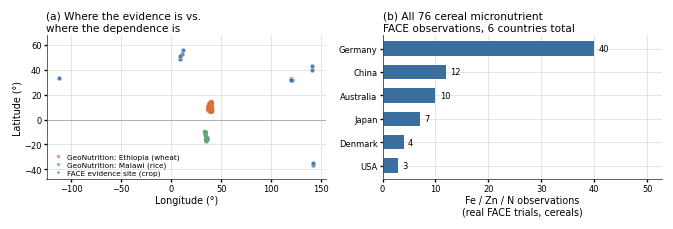

In [7]:
eth_wheat = eth[eth["Crop"] == "Wheat"][["Latitude", "Longitude"]].dropna()
mal_rice = mal[mal["Crop"] == "Rice"][["Latitude", "Longitude"]].dropna()

FS_TITLE = 6.3
FS_LABEL = 5.8
FS_TICK  = 5.0
FS_LEGEND = 4.4
FS_BARVAL = 5.0

fig, axes = plt.subplots(1, 2, figsize=(5.5, 1.80), constrained_layout=True)

ax = axes[0]
for country, sub in crop_ev.groupby("country"):
    pts = sub[["lat", "long"]].drop_duplicates()
    ax.scatter(pts["long"], pts["lat"], s=8, color=PALETTE["face"], alpha=0.85,
               edgecolor="white", linewidth=0.25, zorder=3)
ax.scatter(eth_wheat["Longitude"], eth_wheat["Latitude"], s=2.2, color=PALETTE["geonutrition"],
           alpha=0.55, label="GeoNutrition: Ethiopia (wheat)", zorder=2)
ax.scatter(mal_rice["Longitude"], mal_rice["Latitude"], s=2.2, color=PALETTE["query"],
           alpha=0.55, label="GeoNutrition: Malawi (rice)", zorder=2)
ax.scatter([], [], s=8, color=PALETTE["face"], edgecolor="white", label="FACE evidence site (crop)")
ax.axhline(0, color="#999999", linewidth=0.4, zorder=1)
ax.set_xlim(-125, 155); ax.set_ylim(-48, 68)
ax.set_xlabel("Longitude (°)", fontsize=FS_LABEL, labelpad=1.2)
ax.set_ylabel("Latitude (°)", fontsize=FS_LABEL, labelpad=1.2)
ax.set_title("(a) Where the evidence is vs.\nwhere the dependence is", fontsize=FS_TITLE, fontweight="normal", pad=2.5, loc="left")
ax.tick_params(labelsize=FS_TICK, length=1.8, pad=1.2)
ax.legend(loc="lower left", fontsize=FS_LEGEND, markerscale=0.8, handletextpad=0.25,
          borderpad=0.25, labelspacing=0.2, borderaxespad=0.25)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax = axes[1]
counts = cereal["country"].value_counts().sort_values(ascending=True)
bars = ax.barh(counts.index, counts.values, color=PALETTE["face"], height=0.62)
ax.set_xlabel("Fe / Zn / N observations\n(real FACE trials, cereals)", fontsize=FS_LABEL, labelpad=1.2)
ax.set_title(f"(b) All {len(cereal)} cereal micronutrient\nFACE observations, {len(countries)} countries total",
             fontsize=FS_TITLE, fontweight="normal", pad=2.5, loc="left")
ax.tick_params(labelsize=FS_TICK, length=1.8, pad=1.2)
for b, v in zip(bars, counts.values):
    ax.text(v + 0.8, b.get_y() + b.get_height() / 2, str(v), va="center", fontsize=FS_BARVAL)
ax.set_xlim(0, counts.values.max() * 1.32)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

fig.savefig("figures/fig1_evidential_gap.pdf")  # no bbox_inches="tight" -- keeps it exactly 5.5x1.80in
plt.show()


## 4. The evidential-distance diagnostic, $C(x)$

Training-free by construction: it never sees a nutrient-decline label, only
the geographic coordinates of the real FACE evidence base. A query point's
raw evidential distance is its mean distance (in standardized latitude /
longitude space) to its $k$ nearest FACE sites. We also report a
percentile-style coverage score calibrated against the evidence base's own
leave-one-out distances, but &mdash; with only 14 distinct evidence sites
&mdash; that calibration is necessarily coarse (roughly 1/14-sized steps),
so the continuous raw distance is what later figures plot.


In [8]:

class EvidentialCoverage:
    def __init__(self, k=5):
        self.k = k

    def fit(self, evidence_df):
        self.sites = evidence_df[["lat", "long"]].drop_duplicates().reset_index(drop=True)
        self.scaler = StandardScaler().fit(self.sites.values)
        Xs = self.scaler.transform(self.sites.values)
        k_eff = min(self.k, len(Xs) - 1)
        self.k_eff = k_eff
        self.nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(Xs)
        dists, _ = self.nn.kneighbors(Xs)
        self.ref_distances = dists[:, 1:].mean(axis=1)
        return self

    def raw_distance(self, query_latlong):
        Xq = self.scaler.transform(np.atleast_2d(query_latlong))
        dists, _ = self.nn.kneighbors(Xq, n_neighbors=self.k_eff)
        return dists.mean(axis=1)

    def coverage_score(self, query_latlong):
        d = self.raw_distance(query_latlong)
        ref_sorted = np.sort(self.ref_distances)
        pct = np.searchsorted(ref_sorted, d, side="right") / len(ref_sorted)
        return 1.0 - pct

cov = EvidentialCoverage(k=5).fit(crop_ev)
print(f"Fitted on {len(cov.sites)} distinct FACE evidence sites.")


Fitted on 14 distinct FACE evidence sites.



## 5. A lightweight nutrient-decline predictor, $f(x)$ / $U(x)$

A small RandomForest regressor predicts the fractional change (`delta`) in
Fe, Zn, or N under elevated CO$_2$ from location and CO$_2$-level covariates.
Evaluated with **leave-one-site-out** cross-validation (`GroupKFold` grouped
by the real experimental site, so rows from the same field trial never
leak across the train/test split) &mdash; the only honest way to evaluate
generalization with this few independent sites. Per-tree spread across the
ensemble gives a natural predictive uncertainty $U(x)$.


In [9]:

FEATURES = ["lat", "abs_lat", "long", "eco2", "aco2", "co2_delta"]

def add_engineered(d):
    d = d.copy()
    d["abs_lat"] = d["lat"].abs()
    d["co2_delta"] = d["eco2"] - d["aco2"]
    return d

def build_design_matrix(d):
    d = add_engineered(d)
    elem_dum = pd.get_dummies(d["element"], prefix="elem")
    X = pd.concat([d[FEATURES].reset_index(drop=True), elem_dum.reset_index(drop=True)], axis=1)
    y = d["delta"].reset_index(drop=True).values
    groups = d.apply(lambda r: f"{r['lat']:.2f}_{r['long']:.2f}", axis=1).reset_index(drop=True)
    return X, y, groups

X, y, groups = build_design_matrix(cereal)
X_arr = X.values
n_groups = groups.nunique()
gkf = GroupKFold(n_splits=n_groups)

oof_pred = np.full(len(y), np.nan)
oof_std = np.full(len(y), np.nan)
for train_idx, test_idx in gkf.split(X_arr, y, groups):
    m = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=3, random_state=RNG)
    m.fit(X_arr[train_idx], y[train_idx])
    tree_preds = np.stack([t.predict(X_arr[test_idx]) for t in m.estimators_], axis=0)
    oof_pred[test_idx] = tree_preds.mean(axis=0)
    oof_std[test_idx] = tree_preds.std(axis=0)

final_model = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=3, random_state=RNG)
final_model.fit(X_arr, y)
feature_cols = X.columns.tolist()

mask = ~np.isnan(oof_pred)
cv_r2 = r2_score(y[mask], oof_pred[mask])
cv_mae = mean_absolute_error(y[mask], oof_pred[mask])
print(f"Leave-one-site-out CV (n={n_groups} sites): R2 = {cv_r2:.3f}, MAE = {cv_mae:.3f}")
RESULTS["cv_r2_leave_one_site_out"] = float(cv_r2)
RESULTS["cv_mae_leave_one_site_out"] = float(cv_mae)
RESULTS["cv_n_sites"] = int(n_groups)

def predict_with_uncertainty(lat, long, eco2, aco2, element):
    row = pd.DataFrame([{"lat": lat, "long": long, "eco2": eco2, "aco2": aco2}])
    row = add_engineered(row)
    for c in feature_cols:
        if c.startswith("elem_"):
            row[c] = 1.0 if c == f"elem_{element}" else 0.0
    row = row.reindex(columns=feature_cols, fill_value=0.0).values
    preds = np.array([t.predict(row)[0] for t in final_model.estimators_])
    return preds.mean(), preds.std()


Leave-one-site-out CV (n=11 sites): R2 = -0.332, MAE = 0.124



**Honest read of this number:** a negative leave-one-site-out $R^2$ means the
predictor, evaluated the fairest way available given the data, does not
beat simply predicting the mean decline for a held-out site. That is not a
bug to fix before submission &mdash; it is itself evidence for the paper's
thesis: the real evidence base for cereal micronutrient decline is thin
enough (11 independent sites) that even reproducing its own internal
pattern is hard, well before any question of extrapolating geographically.


## 6. Figure 2 &mdash; method schematic

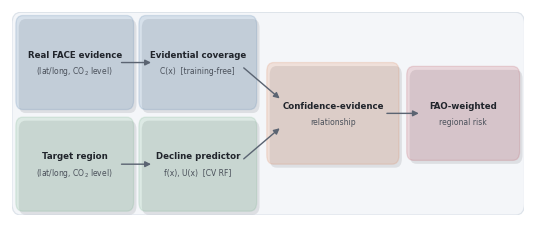

In [10]:
PALETTE = {
    "face": "#3B6FA0", "geonutrition": "#D9713C", "query": "#5FA777",
    "highlight": "#B23A48", "neutral": "#6B6B6B", "grid": "#E4E4E4",
}
BG_FIG = "#FFFFFF"
CARD_BG = "#F4F6F9"
CARD_EDGE = "#DDE3EA"
ARROW_COLOR = "#5B6472"
TEXT_DARK = "#20242B"

SCALE = 5.5 / 7.8  # 0.705

fig, ax = plt.subplots(1, 1, figsize=(5.5, 2.2))
fig.patch.set_facecolor(BG_FIG)
ax.set_xlim(-0.3, 10.3); ax.set_ylim(-0.15, 3.05); ax.axis("off")

# soft rounded "container card" behind the whole diagram
container = mpatches.FancyBboxPatch(
    (-0.28, -0.13), 10.58, 3.15, boxstyle="round,pad=0.02,rounding_size=0.18",
    facecolor=CARD_BG, edgecolor=CARD_EDGE, linewidth=1.0 * SCALE, zorder=0)
ax.add_patch(container)

box_style = dict(boxstyle="round,pad=0.32,rounding_size=0.14", linewidth=1.1 * SCALE)
boxes = [
    (1.0, 2.25, 0.9, 0.42, "Real FACE evidence", "(lat/long, CO$_2$ level)", PALETTE["face"]),
    (1.0, 0.65, 0.9, 0.42, "Target region", "(lat/long, CO$_2$ level)", PALETTE["query"]),
    (3.55, 2.25, 0.9, 0.42, "Evidential coverage", "C(x)  [training-free]", PALETTE["face"]),
    (3.55, 0.65, 0.9, 0.42, "Decline predictor", "f(x), U(x)  [CV RF]", PALETTE["query"]),
    (6.35, 1.45, 1.05, 0.48, "Confidence-evidence", "relationship", PALETTE["geonutrition"]),
    (9.05, 1.45, 0.85, 0.42, "FAO-weighted", "regional risk", PALETTE["highlight"]),
]

# soft drop shadows, drawn behind every box
for x, yv, hw, hh, _, _, color in boxes:
    shadow = mpatches.FancyBboxPatch(
        (x - hw + 0.06, yv - hh - 0.055), 2*hw, 2*hh,
        boxstyle="round,pad=0.32,rounding_size=0.14",
        facecolor="#1A1D22", edgecolor="none", alpha=0.10, zorder=1)
    ax.add_patch(shadow)

for x, yv, hw, hh, line1, line2, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - hw, yv - hh), 2*hw, 2*hh, facecolor=color, alpha=0.16,
        edgecolor=color, zorder=2, **box_style))
    ax.text(x, yv + 0.12, line1, ha="center", va="center", fontsize=7.3 * SCALE,
            fontweight="bold", color=TEXT_DARK, zorder=3)
    ax.text(x, yv - 0.14, line2, ha="center", va="center", fontsize=6.5 * SCALE,
            fontweight="normal", color="#4A505A", zorder=3)

arrows = [(1.9,2.25,2.65,2.25), (1.9,0.65,2.65,0.65), (4.45,2.2,5.3,1.65), (4.45,0.7,5.3,1.25), (7.4,1.45,8.2,1.45)]
for x1,y1,x2,y2 in arrows:
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2), arrowstyle="-|>", mutation_scale=10 * SCALE,
                                  color=ARROW_COLOR, linewidth=1.2 * SCALE,
                                  shrinkA=2, shrinkB=2, zorder=2,
                                  connectionstyle="arc3,rad=0.0", capstyle="round"))

fig.savefig("figures/fig2_method_schematic.pdf", dpi=600)
plt.show()


## 7. Building the query set: FACE-internal sites, GeoNutrition regions,
##    and a few additional real-world growing regions

Coordinates for the four additional regions (India's Punjab wheat belt,
Bangladesh, Vietnam's Mekong Delta, Nigeria's Kano region) are geographic
reference points, not experimental data.


In [11]:

extra_regions = {
    "India (Punjab, wheat belt)": (31.1, 75.3),
    "Bangladesh (Dhaka, rice)": (23.8, 90.4),
    "Vietnam (Mekong Delta, rice)": (10.0, 105.8),
    "Nigeria (Kano, cereals)": (12.0, 8.5),
}
rows = []
for _, r in crop_ev[["lat", "long", "country"]].drop_duplicates().iterrows():
    rows.append((f"FACE site ({r['country']})", r["lat"], r["long"], "face"))
rows.append(("GeoNutrition: Ethiopia (wheat, mean loc.)", eth_wheat["Latitude"].mean(), eth_wheat["Longitude"].mean(), "geonutrition"))
rows.append(("GeoNutrition: Malawi (rice, mean loc.)", mal_rice["Latitude"].mean(), mal_rice["Longitude"].mean(), "geonutrition"))
for name, (lat, lon) in extra_regions.items():
    rows.append((name, lat, lon, "query"))

out = []
for name, lat, lon, kind in rows:
    coverage = cov.coverage_score(np.array([[lat, lon]]))[0]
    raw_d = cov.raw_distance(np.array([[lat, lon]]))[0]
    pmean, pstd = predict_with_uncertainty(lat, lon, 550, 410, "Fe")
    out.append(dict(name=name, lat=lat, lon=lon, kind=kind, coverage=coverage, raw_distance=raw_d, pred_decline=pmean, pred_std=pstd))
query_df = pd.DataFrame(out)
print(f"Query set: {len(query_df)} rows ({query_df['name'].nunique()} unique region names; "
      f"the difference is countries with multiple distinct FACE sites sharing one label).")
query_df.to_csv("results/query_predictions.csv", index=False)
query_df


Query set: 20 rows (12 unique region names; the difference is countries with multiple distinct FACE sites sharing one label).


,name,lat,lon,kind,coverage,raw_distance,pred_decline,pred_std
0,FACE site (Germany),48.700000,9.180000,face,0.571429,0.404780,-0.030501,0.044272
1,FACE site (USA),33.090000,-111.980000,face,0.214286,1.402902,-0.061509,0.072872
2,FACE site (Germany),52.300000,10.430000,face,0.571429,0.385931,-0.024708,0.054531
3,FACE site (China),31.610000,120.470000,face,1.000000,0.014847,-0.188473,0.107426
4,FACE site (Japan),39.730000,140.980000,face,0.642857,0.255832,-0.008472,0.099816
5,FACE site (Japan),43.070000,141.330000,face,0.642857,0.311780,-0.013391,0.093281
6,FACE site (China),32.590000,119.700000,face,1.000000,0.022154,-0.056930,0.068804
7,FACE site (China),32.580000,119.700000,face,1.000000,0.021948,-0.056930,0.068804
8,FACE site (China),31.580000,120.500000,face,1.000000,0.015529,-0.188473,0.107426
9,FACE site (China),31.620000,120.470000,face,1.000000,0.014778,-0.058189,0.065259


## 8. Figure 3 &mdash; validation against real GeoNutrition ground truth

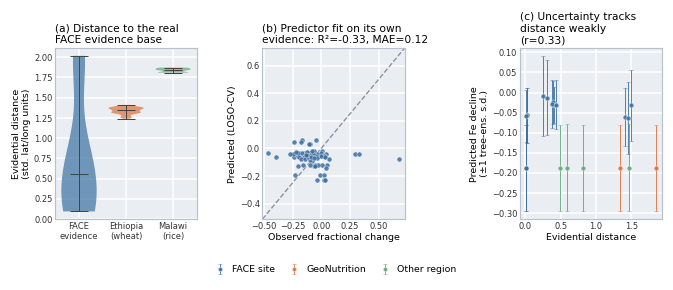

Median evidential distance -- FACE-internal: 0.56  Ethiopia wheat: 1.34  Malawi rice: 1.84
Correlation between evidential distance and the predictor's own ensemble uncertainty: r = 0.33


In [16]:
d_face_internal = cov.ref_distances
d_eth = cov.raw_distance(eth_wheat.values)
d_mal = cov.raw_distance(mal_rice.values)

RESULTS["median_raw_distance_face_internal"] = float(np.median(d_face_internal))
RESULTS["median_raw_distance_ethiopia_wheat"] = float(np.median(d_eth))
RESULTS["median_raw_distance_malawi_rice"] = float(np.median(d_mal))

color_map = {"face": PALETTE["face"], "geonutrition": PALETTE["geonutrition"], "query": PALETTE["query"]}

FS_TITLE = 6.4
FS_LABEL = 5.7
FS_TICK  = 5.0
FS_LEGEND = 5.6

BG_AXES = "#EAEEF3"
BG_FIG = "#FFFFFF"
GRID_COLOR = "#FFFFFF"
SPINE_COLOR = "#B7C0CC"

fig, axes = plt.subplots(1, 3, figsize=(5.5, 2.3), constrained_layout=True)
fig.patch.set_facecolor(BG_FIG)

ax = axes[0]
ax.set_facecolor(BG_AXES)
ax.grid(True, color=GRID_COLOR, linewidth=0.9, zorder=0)
ax.set_axisbelow(True)
groups_to_plot = [("FACE\nevidence", d_face_internal, PALETTE["face"]),
                   ("Ethiopia\n(wheat)", d_eth, PALETTE["geonutrition"]),
                   ("Malawi\n(rice)", d_mal, PALETTE["query"])]
parts = ax.violinplot([g[1] for g in groups_to_plot], positions=[1,2,3], showmedians=True, widths=0.75)
for pc, (_, _, c) in zip(parts["bodies"], groups_to_plot):
    pc.set_facecolor(c); pc.set_alpha(0.7); pc.set_zorder(3)
for key in ["cmedians","cbars","cmins","cmaxes"]:
    parts[key].set_color("#444444"); parts[key].set_linewidth(0.6); parts[key].set_zorder(3)
ax.set_xticks([1,2,3]); ax.set_xticklabels([g[0] for g in groups_to_plot], fontsize=FS_TICK)
ax.set_ylabel("Evidential distance\n(std. lat/long units)", fontsize=FS_LABEL, labelpad=1.5)
ax.set_title("(a) Distance to the real\nFACE evidence base", fontsize=FS_TITLE, fontweight="normal", pad=3, loc="left")
ax.tick_params(labelsize=FS_TICK, length=0, pad=1.5, colors="#333333")
for spine in ax.spines.values(): spine.set_visible(True); spine.set_color(SPINE_COLOR); spine.set_linewidth(0.7)

ax = axes[1]
ax.set_facecolor(BG_AXES)
ax.grid(True, color=GRID_COLOR, linewidth=0.9, zorder=0)
ax.set_axisbelow(True)
ax.scatter(y[mask], oof_pred[mask], s=9, color=PALETTE["face"], alpha=0.85, edgecolor="white", linewidth=0.25, zorder=3)
lims = [min(y[mask].min(), oof_pred[mask].min())-0.05, max(y[mask].max(), oof_pred[mask].max())+0.05]
ax.plot(lims, lims, color="#8A8F98", linewidth=0.8, linestyle="--", zorder=2)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed fractional change", fontsize=FS_LABEL, labelpad=1.5)
ax.set_ylabel("Predicted (LOSO-CV)", fontsize=FS_LABEL, labelpad=1.5)
ax.set_title(f"(b) Predictor fit on its own\nevidence: R²={cv_r2:.2f}, MAE={cv_mae:.2f}", fontsize=FS_TITLE, fontweight="normal", pad=3, loc="left")
ax.tick_params(labelsize=FS_TICK, length=0, pad=1.5, colors="#333333")
for spine in ax.spines.values(): spine.set_visible(True); spine.set_color(SPINE_COLOR); spine.set_linewidth(0.7)

ax = axes[2]
ax.set_facecolor(BG_AXES)
ax.grid(True, color=GRID_COLOR, linewidth=0.9, zorder=0)
ax.set_axisbelow(True)
for kind, sub in query_df.groupby("kind"):
    ax.errorbar(sub["raw_distance"], sub["pred_decline"], yerr=sub["pred_std"], fmt="o", ms=3.0,
                color=color_map[kind], alpha=0.85, capsize=1.4, linewidth=0.6, elinewidth=0.6,
                markeredgecolor="white", markeredgewidth=0.3, zorder=3,
                label={"face":"FACE site","geonutrition":"GeoNutrition","query":"Other region"}[kind])
ax.set_xlabel("Evidential distance", fontsize=FS_LABEL, labelpad=1.5)
ax.set_ylabel("Predicted Fe decline\n(±1 tree-ens. s.d.)", fontsize=FS_LABEL, labelpad=1.5)
dist_std_corr = float(query_df["raw_distance"].corr(query_df["pred_std"]))
ax.set_title(f"(c) Uncertainty tracks\ndistance weakly\n(r={dist_std_corr:.2f})", fontsize=FS_TITLE, fontweight="normal", pad=3, loc="left")
ax.tick_params(labelsize=FS_TICK, length=0, pad=1.5, colors="#333333")
handles, labels = ax.get_legend_handles_labels()
for spine in ax.spines.values(): spine.set_visible(True); spine.set_color(SPINE_COLOR); spine.set_linewidth(0.7)

axes[1].legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3,
               fontsize=FS_LEGEND, markerscale=0.9, handletextpad=0.3, columnspacing=1.0,
               facecolor="white", edgecolor=SPINE_COLOR, framealpha=0.92)

fig.savefig("figures/fig3_mismatch.pdf", dpi=600)
plt.show()
print(f"Median evidential distance -- FACE-internal: {np.median(d_face_internal):.2f}  "
      f"Ethiopia wheat: {np.median(d_eth):.2f}  Malawi rice: {np.median(d_mal):.2f}")
print(f"Correlation between evidential distance and the predictor's own ensemble uncertainty: r = {dist_std_corr:.2f}")


**Honest read of panel (c):** the correlation is positive but weak
($r \approx 0.3$). The RandomForest's ensemble spread is *not* a reliable
stand-in for genuine evidential distance &mdash; it increases only mildly,
and unevenly, as a query point moves farther from the real FACE evidence.
This is a more defensible version of the paper's claim than "the model is
falsely confident": the honest finding is that internal predictive
uncertainty and true evidential coverage are two different things that
correlate weakly, which is precisely the justification for computing $C(x)$
as an independent, training-free diagnostic rather than trusting a model's
self-reported uncertainty.


## 9. Figure 4 &mdash; robustness to the diagnostic's $k$

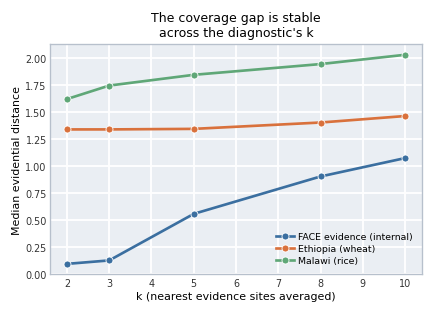

,k,face_internal,ethiopia,malawi
0,2,0.096330,1.339492,1.620334
1,3,0.128310,1.339615,1.745012
2,5,0.558839,1.344607,1.844323
3,8,0.904511,1.403433,1.943778
4,10,1.074428,1.463367,2.029603


In [17]:
ks = [2, 3, 5, 8, 10]
gap_rows = []
for k in ks:
    cov_k = EvidentialCoverage(k=k).fit(crop_ev)
    gap_rows.append({
        "k": k,
        "face_internal": float(np.median(cov_k.ref_distances)),
        "ethiopia": float(np.median(cov_k.raw_distance(eth_wheat.values))),
        "malawi": float(np.median(cov_k.raw_distance(mal_rice.values))),
    })
gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv("results/robustness_by_k.csv", index=False)
RESULTS["robustness_k_values"] = ks

BG_AXES = "#EAEEF3"
BG_FIG = "#FFFFFF"
GRID_COLOR = "#FFFFFF"
SPINE_COLOR = "#B7C0CC"

FS_TITLE = 7.5
FS_LABEL = 6.6
FS_TICK  = 5.8
FS_LEGEND = 5.6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5), constrained_layout=True)
fig.patch.set_facecolor(BG_FIG)
ax.set_facecolor(BG_AXES)
ax.grid(True, color=GRID_COLOR, linewidth=1.1, zorder=0)
ax.set_axisbelow(True)

ax.plot(gap_df["k"], gap_df["face_internal"], marker="o", ms=4.2, linewidth=1.6, color=PALETTE["face"],
        label="FACE evidence (internal)", zorder=3, markeredgecolor="white", markeredgewidth=0.5)
ax.plot(gap_df["k"], gap_df["ethiopia"], marker="o", ms=4.2, linewidth=1.6, color=PALETTE["geonutrition"],
        label="Ethiopia (wheat)", zorder=3, markeredgecolor="white", markeredgewidth=0.5)
ax.plot(gap_df["k"], gap_df["malawi"], marker="o", ms=4.2, linewidth=1.6, color=PALETTE["query"],
        label="Malawi (rice)", zorder=3, markeredgecolor="white", markeredgewidth=0.5)

ax.set_xlabel("k (nearest evidence sites averaged)", fontsize=FS_LABEL, labelpad=2)
ax.set_ylabel("Median evidential distance", fontsize=FS_LABEL, labelpad=2)
ax.set_title("The coverage gap is stable\nacross the diagnostic's k", fontsize=FS_TITLE, fontweight="normal", pad=5)
ax.tick_params(labelsize=FS_TICK, length=0, pad=2, colors="#333333")
ax.legend(fontsize=FS_LEGEND, handletextpad=0.4, borderpad=0.5, labelspacing=0.3, borderaxespad=0.5,
          facecolor="white", edgecolor=SPINE_COLOR, framealpha=0.9)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(SPINE_COLOR)
    spine.set_linewidth(0.8)

fig.savefig("figures/fig4_robustness.pdf", dpi=600)
plt.show()
gap_df


## 10. Real FAO dietary-dependence weighting

This section joins the query regions to real FAOSTAT Food Balance Sheet
data: total cereal food supply (`Cereals - Excl Beer`, kg/capita/yr), the
most recent year available per country. Country names are matched against
FAOSTAT's official `Area` field through an explicit alias table with a
`.contains` fallback; **every match actually used is printed below**, so
the join is auditable rather than a black box. If a country cannot be
matched, its dependence weight is left as `NaN` and it is excluded from the
weighted ranking rather than silently assigned a value.

This section only produces real numbers if Section 1c's FAOSTAT download
succeeded in this runtime. If it did not, it says so plainly and Figure 5
falls back to evidential distance alone.


In [18]:

FAOSTAT_AREA_ALIASES = {
    "India (Punjab, wheat belt)": ["India"],
    "Bangladesh (Dhaka, rice)": ["Bangladesh"],
    "Vietnam (Mekong Delta, rice)": ["Viet Nam", "Vietnam"],
    "Nigeria (Kano, cereals)": ["Nigeria"],
    "GeoNutrition: Ethiopia (wheat, mean loc.)": ["Ethiopia"],
    "GeoNutrition: Malawi (rice, mean loc.)": ["Malawi"],
    "FACE site (Germany)": ["Germany"],
    "FACE site (USA)": ["United States of America", "USA"],
    "FACE site (China)": ["China, mainland", "China"],
    "FACE site (Australia)": ["Australia"],
    "FACE site (Japan)": ["Japan"],
    "FACE site (Denmark)": ["Denmark"],
}

def lookup_cereal_dependence(aliases, fbs_df,
                              item="Cereals - Excl Beer",
                              element="Food supply quantity (kg/capita/yr)"):
    '''Returns (value, matched_area_string, year, item_string_used) or
    (nan, None, None, None) if nothing matches -- never guesses.'''
    sub = fbs_df[fbs_df["Element"] == element]
    if sub.empty:
        sub = fbs_df[fbs_df["Element"].str.contains("Food supply quantity", case=False, na=False)]
    item_sub = sub[sub["Item"] == item]
    if item_sub.empty:
        item_sub = sub[sub["Item"].str.contains("Cereal", case=False, na=False)]
    if item_sub.empty:
        return np.nan, None, None, None
    used_item = item_sub["Item"].iloc[0]
    for alias in aliases:
        match = item_sub[item_sub["Area"].str.strip().str.lower() == alias.strip().lower()]
        if match.empty:
            match = item_sub[item_sub["Area"].str.contains(alias, case=False, na=False, regex=False)]
        if not match.empty:
            latest_year = match["Year"].max()
            val = match[match["Year"] == latest_year]["Value"].iloc[0]
            return float(val), alias, int(latest_year), used_item
    return np.nan, None, None, used_item

if faostat_available:
    # Build the lookup over UNIQUE names only -- query_df has multiple rows
    # sharing the same name for countries with several FACE sites (e.g. 5
    # distinct China sites all named "FACE site (China)"), and merging two
    # frames on a non-unique key multiplies matching rows (5x5=25 instead of
    # 5). A name -> value mapping applied with .map() cannot do that: each
    # row gets looked up independently, so row count is preserved exactly.
    unique_names = query_df["name"].unique()
    dep_rows = []
    for name in unique_names:
        aliases = FAOSTAT_AREA_ALIASES.get(name, [])
        val, matched, yr, item_used = lookup_cereal_dependence(aliases, food_balance)
        dep_rows.append(dict(name=name, cereal_kg_per_capita_yr=val, matched_area=matched, matched_year=yr, matched_item=item_used))
        status = "OK" if not np.isnan(val) else "NO MATCH"
        print(f"[{status}] {name:45s} -> Area='{matched}', Item='{item_used}', Year={yr}, Value={val}")
    dep_df = pd.DataFrame(dep_rows).drop_duplicates(subset="name")
    value_map = dep_df.set_index("name")["cereal_kg_per_capita_yr"]
    assert len(query_df) == len(query_df["name"].map(value_map)), "row count changed -- lookup must be 1:1"
    query_df["cereal_kg_per_capita_yr"] = query_df["name"].map(value_map)
    n_unmatched = int(query_df["cereal_kg_per_capita_yr"].isna().sum())
    RESULTS["faostat_n_unmatched_regions"] = n_unmatched
    if n_unmatched > 0:
        print(f"\nWARNING: {n_unmatched} row(s) had no FAOSTAT match -- excluded from the weighted ranking below.")
else:
    query_df["cereal_kg_per_capita_yr"] = np.nan
    print("FAOSTAT unavailable in this runtime -- dependence weights left as NaN.")

query_df.to_csv("results/query_predictions.csv", index=False)
query_df


[OK] FACE site (Germany)                           -> Area='Germany', Item='Cereals - Excluding Beer', Year=2023, Value=100.29
[OK] FACE site (USA)                               -> Area='United States of America', Item='Cereals - Excluding Beer', Year=2023, Value=129.86
[OK] FACE site (China)                             -> Area='China, mainland', Item='Cereals - Excluding Beer', Year=2023, Value=218.57
[NO MATCH] FACE site (Japan)                             -> Area='None', Item='Cereals - Excluding Beer', Year=None, Value=nan
[OK] FACE site (Australia)                         -> Area='Australia', Item='Cereals - Excluding Beer', Year=2023, Value=115.4
[OK] FACE site (Denmark)                           -> Area='Denmark', Item='Cereals - Excluding Beer', Year=2023, Value=131.66
[OK] GeoNutrition: Ethiopia (wheat, mean loc.)     -> Area='Ethiopia', Item='Cereals - Excluding Beer', Year=2023, Value=209.02
[OK] GeoNutrition: Malawi (rice, mean loc.)        -> Area='Malawi', Item='Cereals -

,name,lat,lon,kind,coverage,raw_distance,pred_decline,pred_std,cereal_kg_per_capita_yr
0,FACE site (Germany),48.700000,9.180000,face,0.571429,0.404780,-0.030501,0.044272,100.29
1,FACE site (USA),33.090000,-111.980000,face,0.214286,1.402902,-0.061509,0.072872,129.86
2,FACE site (Germany),52.300000,10.430000,face,0.571429,0.385931,-0.024708,0.054531,100.29
3,FACE site (China),31.610000,120.470000,face,1.000000,0.014847,-0.188473,0.107426,218.57
4,FACE site (Japan),39.730000,140.980000,face,0.642857,0.255832,-0.008472,0.099816,NaN
5,FACE site (Japan),43.070000,141.330000,face,0.642857,0.311780,-0.013391,0.093281,NaN
6,FACE site (China),32.590000,119.700000,face,1.000000,0.022154,-0.056930,0.068804,218.57
7,FACE site (China),32.580000,119.700000,face,1.000000,0.021948,-0.056930,0.068804,218.57
8,FACE site (China),31.580000,120.500000,face,1.000000,0.015529,-0.188473,0.107426,218.57
9,FACE site (China),31.620000,120.470000,face,1.000000,0.014778,-0.058189,0.065259,218.57



## 11. Figure 5 &mdash; regional risk view

When FAOSTAT weighting is available, this combines evidential distance
(Section 4) with real dietary-dependence weight (Section 10) into a single
risk score &mdash; both components min-max normalized to [0, 1] across the
query regions, then multiplied &mdash; and shows it as a two-panel figure
(the raw relationship, then the ranking it produces). This is the "silent
malnutrition exposure" view the method targets. When FAOSTAT weighting is
not available in this runtime, the cell below produces a single honest
panel of evidential distance alone, rather than padding out a second panel
with nothing real to show.


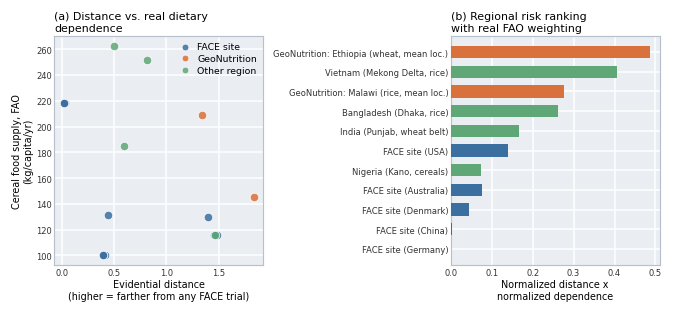

In [19]:
has_weights = faostat_available and query_df["cereal_kg_per_capita_yr"].notna().any()

d = query_df.copy()
d["dist_norm"] = (d["raw_distance"] - d["raw_distance"].min()) / (d["raw_distance"].max() - d["raw_distance"].min())
if has_weights:
    valid = d["cereal_kg_per_capita_yr"].notna()
    d.loc[valid, "dep_norm"] = (
        (d.loc[valid, "cereal_kg_per_capita_yr"] - d.loc[valid, "cereal_kg_per_capita_yr"].min())
        / (d.loc[valid, "cereal_kg_per_capita_yr"].max() - d.loc[valid, "cereal_kg_per_capita_yr"].min() + 1e-9)
    )
    d["risk_score"] = d["dist_norm"] * d["dep_norm"]
else:
    d["risk_score"] = d["dist_norm"]

FS_TITLE = 6.6
FS_LABEL = 5.8
FS_TICK  = 5.0
FS_LEGEND = 5.6

BG_AXES = "#EAEEF3"
BG_FIG = "#FFFFFF"
GRID_COLOR = "#FFFFFF"
SPINE_COLOR = "#B7C0CC"

if has_weights:
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), constrained_layout=True)
    fig.patch.set_facecolor(BG_FIG)

    ax = axes[0]
    ax.set_facecolor(BG_AXES)
    ax.grid(True, color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    for kind, sub in d.groupby("kind"):
        ax.scatter(sub["raw_distance"], sub["cereal_kg_per_capita_yr"], s=26, color=color_map[kind], alpha=0.85,
                   edgecolor="white", linewidth=0.5, zorder=3,
                   label={"face":"FACE site","geonutrition":"GeoNutrition","query":"Other region"}[kind])
    ax.set_xlabel("Evidential distance\n(higher = farther from any FACE trial)", fontsize=FS_LABEL, labelpad=1.5)
    ax.set_ylabel("Cereal food supply, FAO\n(kg/capita/yr)", fontsize=FS_LABEL, labelpad=1.5)
    ax.set_title("(a) Distance vs. real dietary\ndependence", fontsize=FS_TITLE, fontweight="normal", pad=3, loc="left")
    ax.tick_params(labelsize=FS_TICK, length=0, pad=1.5, colors="#333333")
    ax.legend(loc="upper right", fontsize=FS_LEGEND, markerscale=0.8, handletextpad=0.3, borderpad=0.35,
              labelspacing=0.3, borderaxespad=0.35, facecolor="white", edgecolor=SPINE_COLOR, framealpha=0.92)
    for spine in ax.spines.values(): spine.set_visible(True); spine.set_color(SPINE_COLOR); spine.set_linewidth(0.7)

    ax = axes[1]
    ax.set_facecolor(BG_AXES)
    ax.grid(True, color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    order = d.sort_values("risk_score", ascending=True)
    colors = order["kind"].map(color_map)
    ax.barh(order["name"], order["risk_score"], color=colors, height=0.62, zorder=3)
    ax.set_xlabel("Normalized distance x\nnormalized dependence", fontsize=FS_LABEL, labelpad=1.5)
    ax.set_title("(b) Regional risk ranking\nwith real FAO weighting", fontsize=FS_TITLE, fontweight="normal", pad=3, loc="left")
    ax.tick_params(labelsize=FS_TICK, length=0, pad=1.5, colors="#333333")
    for spine in ax.spines.values(): spine.set_visible(True); spine.set_color(SPINE_COLOR); spine.set_linewidth(0.7)
else:
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2.5), constrained_layout=True)
    fig.patch.set_facecolor(BG_FIG)
    ax.set_facecolor(BG_AXES)
    ax.grid(True, color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    order = d.sort_values("risk_score", ascending=True)
    colors = order["kind"].map(color_map)
    ax.barh(order["name"], order["raw_distance"], color=colors, height=0.62, zorder=3)
    ax.set_xlabel("Evidential distance\n(higher = farther from any real FACE trial)", fontsize=FS_LABEL, labelpad=1.5)
    ax.set_title("Regional evidential distance\n(FAO dependence weighting unavailable this run)", fontsize=FS_TITLE, fontweight="normal", pad=3)
    ax.tick_params(labelsize=FS_TICK, length=0, pad=1.5, colors="#333333")
    for spine in ax.spines.values(): spine.set_visible(True); spine.set_color(SPINE_COLOR); spine.set_linewidth(0.7)

fig.savefig("figures/fig5_regional_risk.pdf", dpi=600)
plt.show()
RESULTS["fig5_used_real_faostat_weights"] = bool(has_weights)

## 12. Save results and package outputs

In [20]:

with open("results/results.json", "w") as f:
    json.dump(RESULTS, f, indent=2)
print(json.dumps(RESULTS, indent=2))


{
  "faostat_available": true,
  "n_face_crop_obs": 295,
  "n_face_crop_sites": 14,
  "face_countries": [
    "Australia",
    "China",
    "Denmark",
    "Germany",
    "Japan",
    "USA"
  ],
  "n_cereal_micronutrient_obs": 76,
  "n_cereal_micronutrient_sites": 11,
  "cv_r2_leave_one_site_out": -0.3324915118972984,
  "cv_mae_leave_one_site_out": 0.12352926400675991,
  "cv_n_sites": 11,
  "median_raw_distance_face_internal": 0.5588386263183834,
  "median_raw_distance_ethiopia_wheat": 1.3446068297728315,
  "median_raw_distance_malawi_rice": 1.8443230724876056,
  "robustness_k_values": [
    2,
    3,
    5,
    8,
    10
  ],
  "faostat_n_unmatched_regions": 2,
  "fig5_used_real_faostat_weights": true
}


In [21]:

import shutil, zipfile
shutil.make_archive("hidden_hunger_hidden_uncertainty_results", "zip", ".", "figures")
with zipfile.ZipFile("hidden_hunger_hidden_uncertainty_results.zip", "a") as zf:
    for fn in os.listdir("results"):
        zf.write(os.path.join("results", fn), os.path.join("results", fn))
print("Wrote hidden_hunger_hidden_uncertainty_results.zip")


Wrote hidden_hunger_hidden_uncertainty_results.zip



## Limitations (for the paper's Limitations section)

- The FACE evidence base for cereal Fe/Zn/N response is genuinely small (11
  independent field sites, 6 countries); the leave-one-site-out $R^2$ for
  the decline predictor is negative, meaning any point prediction from it
  should be treated as illustrative, not calibrated.
- GeoNutrition is a cross-sectional micronutrient survey, not a CO$_2$
  manipulation experiment; it validates that the target regions are
  evidentially uncovered, not that the CO$_2$-decline mechanism itself
  operates identically there.
- The evidential-distance diagnostic uses only latitude/longitude as the
  covariate space; a version incorporating climate reanalysis covariates
  (temperature, precipitation trends) would be a natural extension.
- The FAO dependence weighting uses total cereal supply (kg/capita/yr) as a
  single crop-agnostic proxy rather than matching each region to its
  specific staple (wheat vs. rice); this was a deliberate simplification to
  keep the country-matching logic auditable, noted here as a direction for
  refinement.
- Regional risk ranking (Fig. 5) depends on FAOSTAT access at run time; the
  notebook reports plainly whether real weights were used for the version
  being read.
